# 📘 Trabalho T2 – Teorema do Limite Central (TLC)

Este trabalho tem como objetivo investigar, por meio de simulações, o comportamento da distribuição das médias amostrais.

### **Atenção:** esse trabalho **obrigatoriamente** deve ser realizado por um grupo de **no mínimo 2** e **no máximo 3** alunos.

## Parte 1 — Identificação da equipe

In [37]:
# Aluno 1:
# Aluno 2:
# Aluno 3:

## Parte 2 — Identificação do líder da equipe

Anote o RA **apenas do aluno** que vai entregar o trabalho no Canvas

In [38]:
# Atenção, esse RA vai ser usado no controle randômico do trabalho, coloque o RA correto do líder da equipe
RA = 26000001

## Parte 3 — Bibliotecas

In [39]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm


## Parte 4 — Geração de populações para serem usados pelo grupo

- **Execute a célula para carregar 2 populações customizadas para sua equipe**

In [40]:
random.seed(RA)

pop_normal = [random.gauss(50, 10) for i in range(10000)]

pop_exponencial = [random.expovariate(1/50) for i in range(10000)]



## Parte 5 — Visualização das populações

**Observe** os histogramas das 2 populações abaixo.

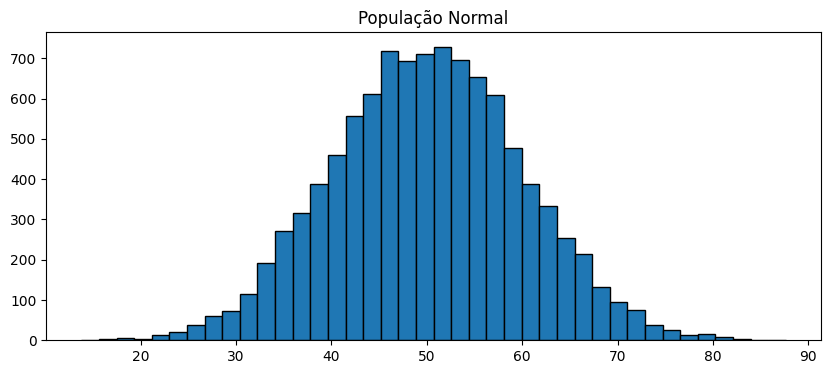

In [41]:
plt.figure(figsize=(10,4))
plt.hist(pop_normal, bins=40, edgecolor="black")
plt.title("População Normal")
plt.show()

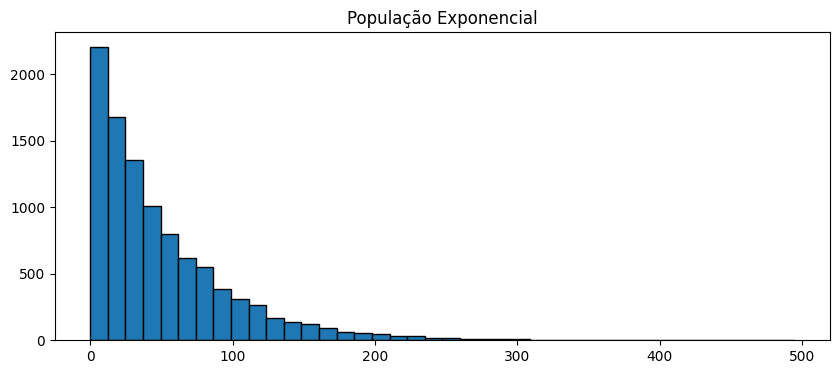

In [42]:
plt.figure(figsize=(10,4))
plt.hist(pop_exponencial, bins=40, edgecolor="black")
plt.title("População Exponencial")
plt.show()

## Parte 6 — Simulação das médias amostrais

Nesta parte, vocês vão investigar o **Teorema do Limite Central (TLC)** por meio de simulações.

**`Para cada população`**, vocês devem trabalhar com:

```python
n_amostras = 1000
tamanhos_n = [16, 25, 36, 100, 400]
```

**`Para cada valor de n`**, vocês devem:

1. selecionar 1000 amostras de tamanho `n`;
2. calcular a média de cada amostra;
3. guardar as 1000 médias em uma lista;
4. construir histogramas das médias amostrais;
5. comparar o comportamento observado com o que é previsto pelo TLC.

Atenção: sempre que possível, usem `stat = "density"` nos histogramas das médias amostrais, pois isso facilita a comparação com a curva normal teórica.


In [43]:
# Parâmetros gerais do trabalho
n_amostras = 1000  # número de amostras por simulação
tamanhos_n = [16, 25, 36, 100, 400]


### **Problema 1 — População normal**

Utilizando a **`pop_normal`** dada acima, faça o que se pede.


a) Calcule a média **mu** da população com uma casa decimal.


In [44]:
mu = round(np.mean(pop_normal), 1)
print(f"Média da população normal: mu = {mu}")

Média da população normal: mu = 50.1


b) Calcule o desvio padrão **sigma** da população com uma casa decimal.


In [45]:
sigma = round(np.std(pop_normal, ddof=1), 1)
print(f"Desvio padrão da população normal: sigma = {sigma}")

Desvio padrão da população normal: sigma = 9.9


c) Para cada valor de `n` na lista `tamanhos_n`, selecione **1000 amostras** da `população normal`. Calcule a média de cada amostra e guarde os resultados.

Sugestão de organização: crie um dicionário em que cada chave seja o valor de `n` e cada valor seja a lista com as 1000 médias amostrais.

Exemplo de estrutura esperada:

```python
medias_normal = {}
medias_normal[16] = [...]
medias_normal[25] = [...]
...
```


In [46]:
medias_normal = {}                                                          # cria um dicionário vazio pra guardar tudo organizado

for n in tamanhos_n:                                                        # passa por cada valor: 16, 25, 36, 100, 400
    lista_de_medias = []                                                        # cria uma lista vazia pra guardar as 1000 médias desse n

    for i in range(n_amostras):                                                 #repete 1000 vezes
        amostra = random.choices(pop_normal, k=n)                                   # orteia n números da população com reposição
        media = np.mean(amostra)                                                    # calcula a média dos n números sorteados
        lista_de_medias.append(media)                                               # anota essa média na lista

    medias_normal[n] = lista_de_medias                                          # guarda as 1000 médias no dicionário com a chave n

c-1) Faça os histogramas das médias amostrais **lado a lado**, um para cada valor de `n`.

Observe visualmente:

- a forma da distribuição das médias;
- a concentração das médias em torno da média populacional;
- a redução da dispersão quando `n` aumenta.


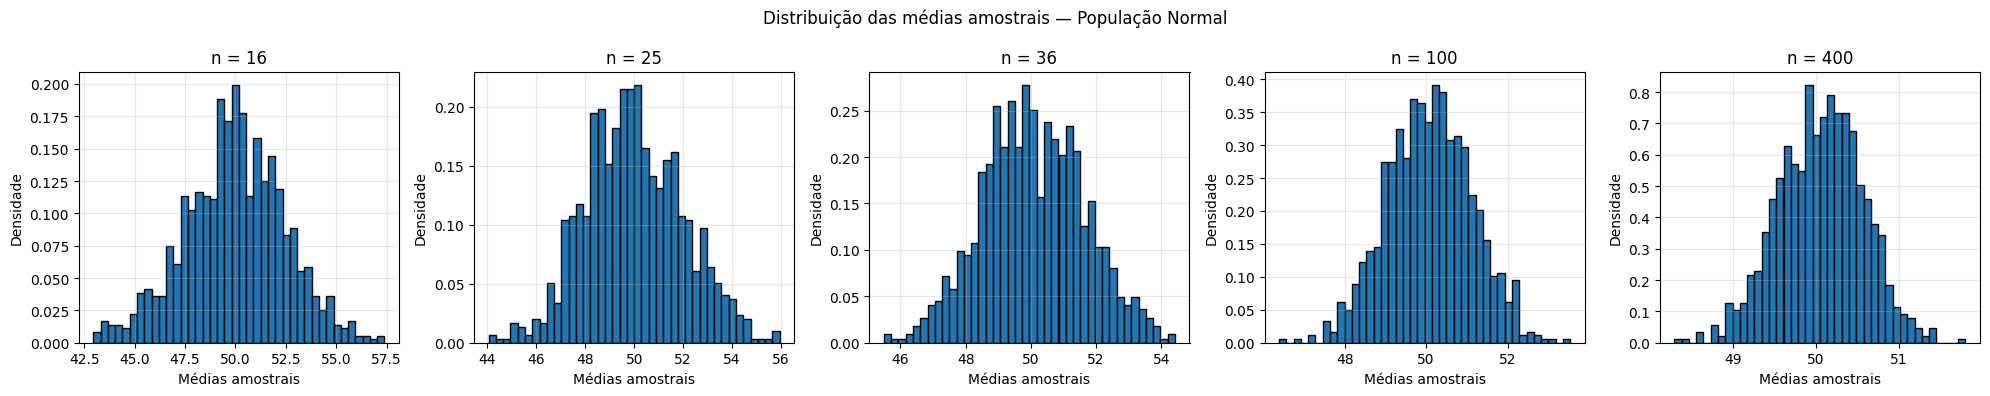

In [47]:
plt.figure(figsize=(20, 4))

i = 0
for n in tamanhos_n:
    plt.subplot(1, 5, i+1)
    plt.hist(medias_normal[n], bins=40, density=True, edgecolor="black")
    plt.title(f"n = {n}")
    plt.xlabel("Médias amostrais")
    plt.ylabel("Densidade")
    plt.grid(alpha=0.3)
    i += 1

plt.suptitle("Distribuição das médias amostrais -- População Normal")
plt.tight_layout()
plt.show()

c-2) Em cada histograma, sobreponha a **curva normal teórica** prevista pelo TLC.

Para isso, use:

- média teórica: `mu`;
- desvio padrão teórico das médias: `sigma / sqrt(n)`.

A curva normal teórica deve ajudar vocês a comparar a distribuição simulada das médias com a aproximação prevista pelo Teorema do Limite Central.


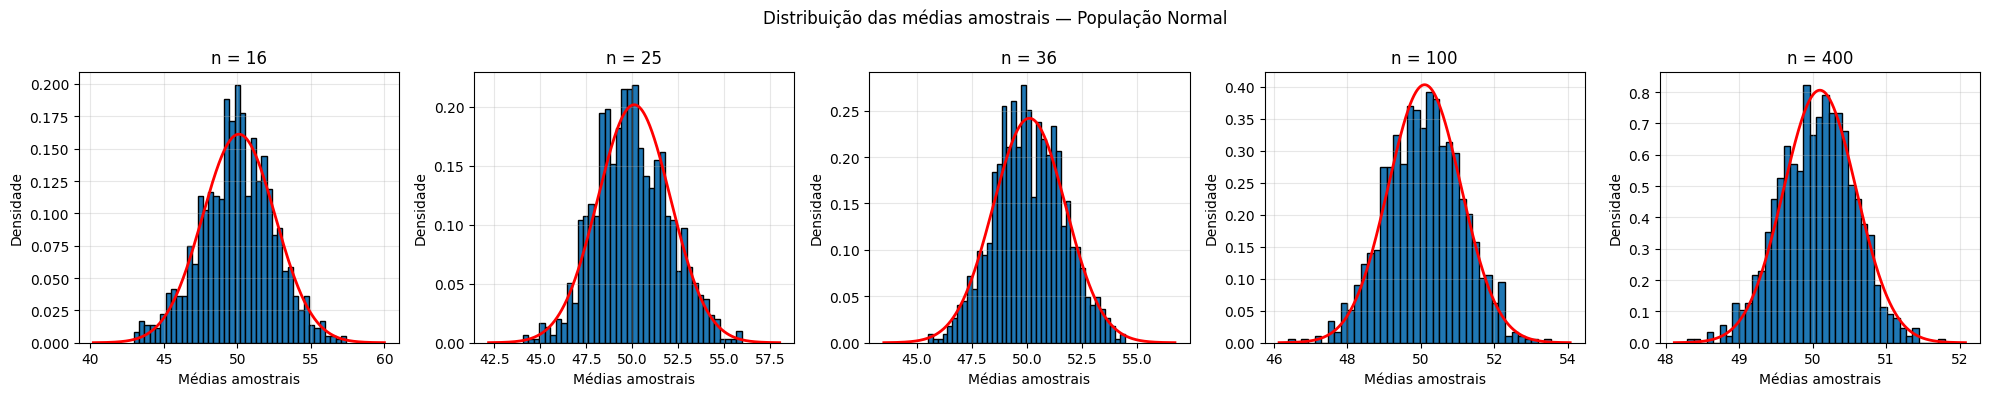

In [48]:
plt.figure(figsize=(20, 4))

i = 0
for n in tamanhos_n:
    epm_teorico = sigma / np.sqrt(n)

    x = np.linspace(mu - 4*epm_teorico, mu + 4*epm_teorico, 1000)
    y = norm.pdf(x, loc=mu, scale=epm_teorico)

    plt.subplot(1, 5, i+1)
    plt.hist(medias_normal[n], bins=40, density=True, edgecolor="black")
    plt.plot(x, y, color="red", linewidth=2)
    plt.title(f"n = {n}")
    plt.xlabel("Médias amostrais")
    plt.ylabel("Densidade")
    plt.grid(alpha=0.3)
    i += 1

plt.suptitle("Distribuição das médias amostrais -- População Normal")
plt.tight_layout()
plt.show()

c-3) A distribuição das médias amostrais parece normal para todos os valores de `n`?

Responda com base nos histogramas e na comparação com a curva normal teórica. Comente especialmente o que acontece quando `n` aumenta.


In [49]:
# Sim. Para todos os valores de n, a distribuição das médias amostrais já se parece com uma normal, pois a população de origem também é normal. Quando n aumenta, a distribuição fica mais estreita e concentrada em torno de mu = 50.1, e a curva teórica (vermelha) encaixa cada vez melhor nas barras do histograma.

c-4) Calcule a **média das médias amostrais** para cada valor de `n`.

Depois, compare esses valores com a média populacional `mu`.

Monte uma tabela com as colunas:

| n | média das médias | média populacional |
|---|---:|---:|


In [50]:
dados = []

for n in tamanhos_n:
    media_das_medias = round(np.mean(medias_normal[n]), 2)
    dados.append([n, media_das_medias, mu])

tabela = pd.DataFrame(dados, columns=["n", "média das médias", "média populacional"])
print(tabela)

     n  média das médias  média populacional
0   16             49.95                50.1
1   25             49.98                50.1
2   36             50.08                50.1
3  100             50.07                50.1
4  400             50.05                50.1


c-5) Calcule o **EPM observado** e o **EPM teórico** para cada valor de `n`.

- EPM observado: desvio padrão das 1000 médias amostrais;
- EPM teórico: `sigma / sqrt(n)`.

Monte uma tabela com as colunas:

| n | EPM observado | EPM teórico |
|---|---:|---:|

Essa comparação permite verificar se o comportamento observado nas simulações é consistente com o que o TLC prevê.


In [51]:
dados = []

for n in tamanhos_n:
    epm_obs = round(np.std(medias_normal[n]), 2)
    epm_teo = round(sigma / np.sqrt(n), 2)
    dados.append([n, epm_obs, epm_teo])

tabela_epm = pd.DataFrame(dados, columns=["n", "EPM observado", "EPM teórico"])
print(tabela_epm)

     n  EPM observado  EPM teórico
0   16           2.48         2.48
1   25           1.99         1.98
2   36           1.56         1.65
3  100           1.04         0.99
4  400           0.51         0.50


c-6) Faça um gráfico comparando o **EPM observado** e o **EPM teórico** em função de `n`.

No eixo x, coloque os valores de `n`. No eixo y, coloque o EPM.

Esse gráfico deve mostrar a queda da variabilidade das médias amostrais quando o tamanho da amostra aumenta.


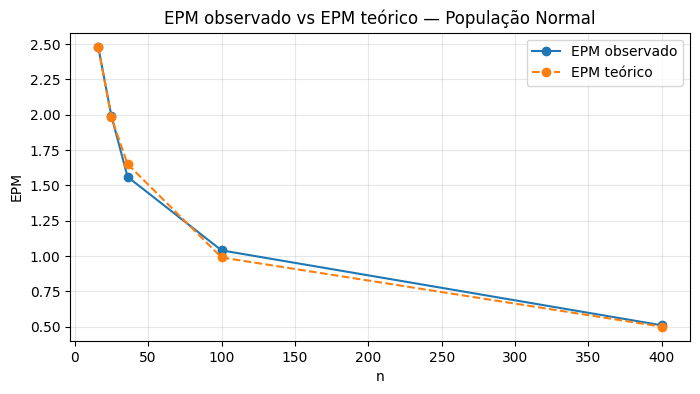

In [52]:
epms_obs = []
epms_teo = []

for n in tamanhos_n:
    epms_obs.append(round(np.std(medias_normal[n]), 2))
    epms_teo.append(round(sigma / np.sqrt(n), 2))

plt.figure(figsize=(8, 4))
plt.plot(tamanhos_n, epms_obs, marker="o", label="EPM observado")
plt.plot(tamanhos_n, epms_teo, marker="o", label="EPM teórico", linestyle="--")
plt.title("EPM observado vs EPM teórico -- População Normal")
plt.xlabel("n")
plt.ylabel("EPM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

c-7) O desvio padrão das médias amostrais se aproxima do valor previsto pelo TLC?

Explique usando a tabela e o gráfico do EPM observado versus EPM teórico.


In [53]:
# Sim. Como podemos ver na tabela e no gráfico, o EPM observado ficou muito próximo do EPM teórico em todos os valores de n. A maior diferença foi em n = 36, onde o EPM observado foi 1.56 e o teórico foi 1.65, uma diferença de apenas 0.09, cerca de 5.5%. Isso confirma o que o TLC prevê: o desvio padrão das médias amostrais é igual a sigma / sqrt(n).

### **Problema 2 — População exponencial**

Utilizando a **`pop_exponencial`** dada acima, faça o que se pede.


a) Calcule a média **mu** da população com uma casa decimal.


In [54]:
mu = round(np.mean(pop_exponencial), 1)
print(f"Média da população exponencial: mu = {mu}")

Média da população exponencial: mu = 49.9


b) Calcule o desvio padrão **sigma** da população com uma casa decimal.


In [55]:
sigma = round(np.std(pop_exponencial, ddof=1), 1)
print(f"Desvio padrão da população exponencial: sigma = {sigma}")

Desvio padrão da população exponencial: sigma = 49.5


c) Para cada valor de `n` na lista `tamanhos_n`, selecione **1000 amostras** da `população exponencial`. Calcule a média de cada amostra e guarde os resultados.

Sugestão de organização: crie um dicionário em que cada chave seja o valor de `n` e cada valor seja a lista com as 1000 médias amostrais.

Exemplo de estrutura esperada:

```python
medias_exponencial = {}
medias_exponencial[16] = [...]
medias_exponencial[25] = [...]
...
```


In [56]:
medias_exponenciais = {}                                                          # cria um dicionário vazio pra guardar tudo organizado

for n in tamanhos_n:                                                        # passa por cada valor: 16, 25, 36, 100, 400
    lista_de_medias_exp = []                                                        # cria uma lista vazia pra guardar as 1000 médias desse n

    for i in range(n_amostras):                                                 #repete 1000 vezes
        amostra = random.choices(pop_exponencial, k=n)                                   # orteia n números da população com reposição
        media = np.mean(amostra)                                                    # calcula a média dos n números sorteados
        lista_de_medias_exp.append(media)                                               # anota essa média na lista

    medias_exponenciais[n] = lista_de_medias_exp                                          # guarda as 1000 médias no dicionário com a chave n

c-1) Faça os histogramas das médias amostrais **lado a lado**, um para cada valor de `n`.

Observe visualmente:

- a forma da distribuição das médias;
- a concentração das médias em torno da média populacional;
- a redução da dispersão quando `n` aumenta.


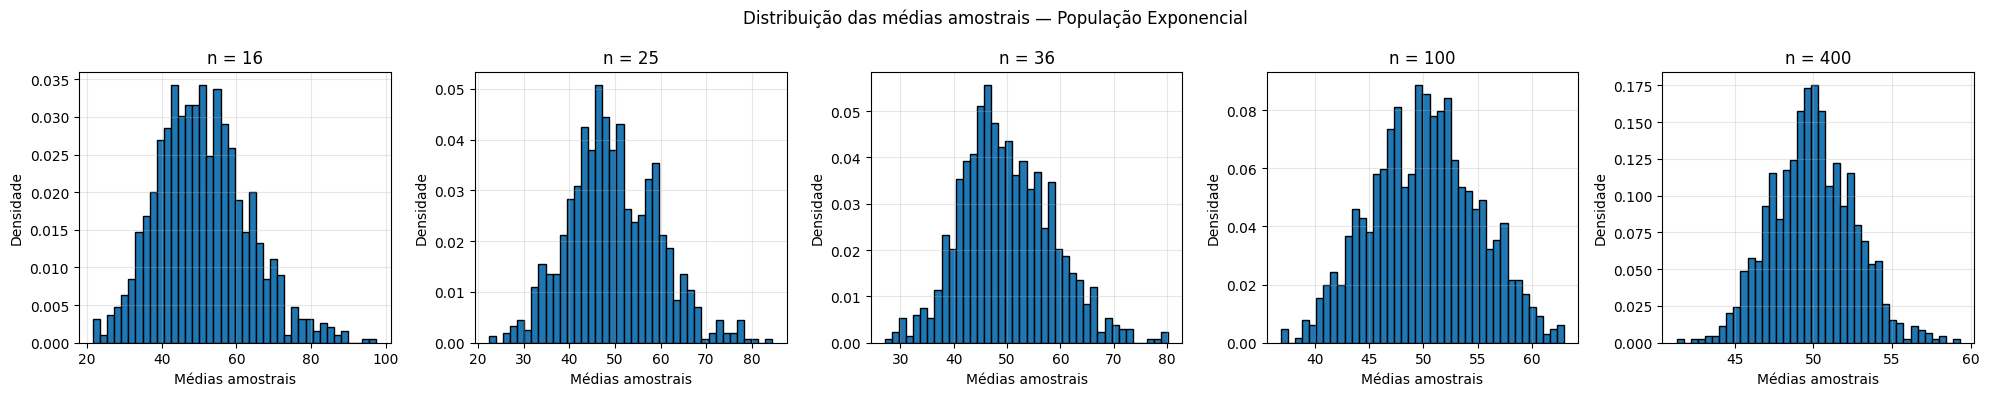

In [57]:
plt.figure(figsize=(20, 4))

i = 0
for n in tamanhos_n:
    plt.subplot(1, 5, i+1)
    plt.hist(medias_exponenciais[n], bins=40, density=True, edgecolor="black")
    plt.title(f"n = {n}")
    plt.xlabel("Médias amostrais")
    plt.ylabel("Densidade")
    plt.grid(alpha=0.3)
    i += 1

plt.suptitle("Distribuição das médias amostrais -- População Exponencial")
plt.tight_layout()
plt.show()

c-2) Em cada histograma, sobreponha a **curva normal teórica** prevista pelo TLC.

Para isso, use:

- média teórica: `mu`;
- desvio padrão teórico das médias: `sigma / sqrt(n)`.

A curva normal teórica deve ajudar vocês a comparar a distribuição simulada das médias com a aproximação prevista pelo Teorema do Limite Central.


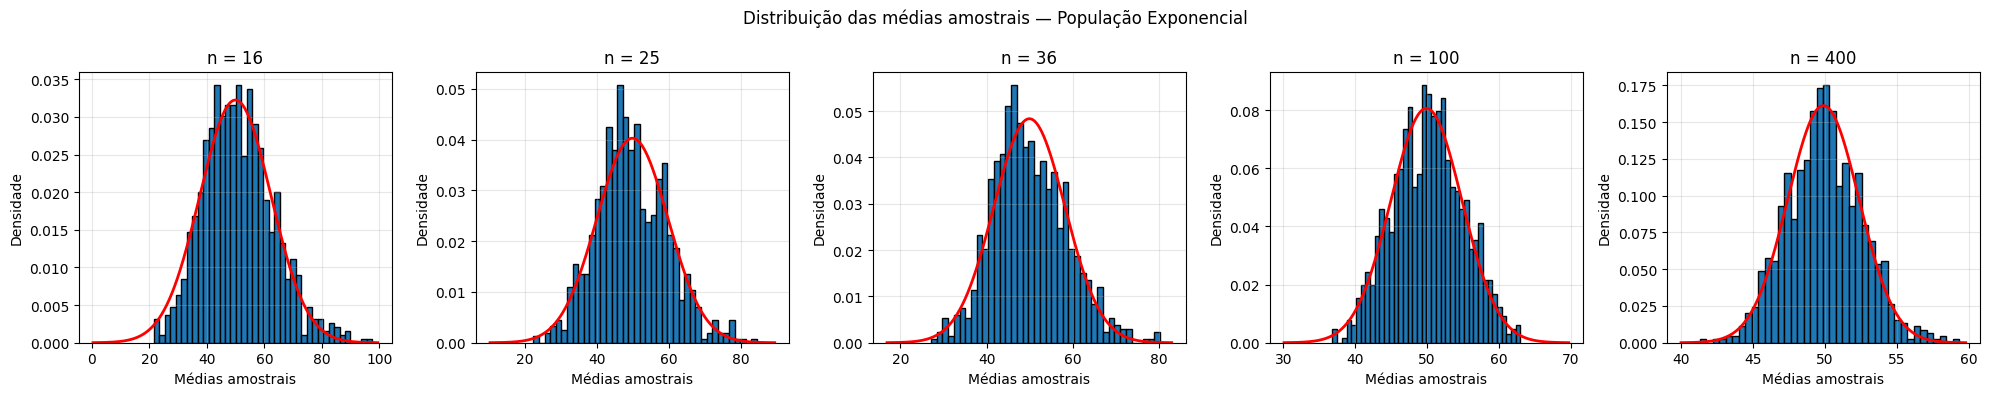

In [58]:
plt.figure(figsize=(20, 4))

i = 0
for n in tamanhos_n:
    epm_teorico = sigma / np.sqrt(n)
    x = np.linspace(mu - 4*epm_teorico, mu + 4*epm_teorico, 1000)
    y = norm.pdf(x, loc=mu, scale=epm_teorico)

    plt.subplot(1, 5, i+1)
    plt.hist(medias_exponenciais[n], bins=40, density=True, edgecolor="black")
    plt.plot(x, y, color="red", linewidth=2)
    plt.title(f"n = {n}")
    plt.xlabel("Médias amostrais")
    plt.ylabel("Densidade")
    plt.grid(alpha=0.3)
    i += 1

plt.suptitle("Distribuição das médias amostrais -- População Exponencial")
plt.tight_layout()
plt.show()

c-3) A distribuição das médias amostrais parece normal para todos os valores de `n`?

Responda com base nos histogramas e na comparação com a curva normal teórica. Comente especialmente o que acontece quando `n` aumenta.


In [60]:
# Diferente da população normal, para n pequenos (n=16, n=25) a distribuição das médias é muito mais assimetrica, a curva indo de 0 a 100 enquanto quando vimos la em cima na população normal, era muito mais estreito que isso desde o começo e alem disso a curva normal teórica não encaixa bem nas barras da população exponencial. Isso acontece porque a população exponencial é muito assimétrica, diferente da normal. Conforme n aumenta (n=100, n=400), a distribuição das médias vai ficando mais simétrica e concentrada em torno de mu, e a curva teórica passa a encaixar cada vez melhor, isso confirma o TLC: mesmo partindo de uma população assimétrica, as médias amostrais convergem pra normal quando n é suficientemente grande.

c-4) Calcule a **média das médias amostrais** para cada valor de `n`.

Depois, compare esses valores com a média populacional `mu`.

Monte uma tabela com as colunas:

| n | média das médias | média populacional |
|---|---:|---:|


In [64]:
dados = []

for n in tamanhos_n:
    media_das_medias = round(np.mean(medias_exponenciais[n]), 2)
    dados.append([n, media_das_medias, mu])

tabela = pd.DataFrame(dados, columns=["n", "média das médias", "média populacional (exponencial)"])
print(tabela)

     n  média das médias  média populacional (exponencial)
0   16             51.00                              49.9
1   25             49.69                              49.9
2   36             49.92                              49.9
3  100             50.10                              49.9
4  400             49.96                              49.9


c-5) Calcule o **EPM observado** e o **EPM teórico** para cada valor de `n`.

- EPM observado: desvio padrão das 1000 médias amostrais;
- EPM teórico: `sigma / sqrt(n)`.

Monte uma tabela com as colunas:

| n | EPM observado | EPM teórico |
|---|---:|---:|

Essa comparação permite verificar se o comportamento observado nas simulações é consistente com o que o TLC prevê.


In [65]:
dados = []

for n in tamanhos_n:
    epm_obs = round(np.std(medias_exponenciais[n]), 2)
    epm_teo = round(sigma / np.sqrt(n), 2)
    dados.append([n, epm_obs, epm_teo])

tabela_epm = pd.DataFrame(dados, columns=["n", "EPM observado", "EPM teórico"])
print(tabela_epm)

     n  EPM observado  EPM teórico
0   16          12.26        12.38
1   25           9.80         9.90
2   36           8.52         8.25
3  100           4.89         4.95
4  400           2.61         2.48


c-6) Faça um gráfico comparando o **EPM observado** e o **EPM teórico** em função de `n`.

No eixo x, coloque os valores de `n`. No eixo y, coloque o EPM.

Esse gráfico deve mostrar a queda da variabilidade das médias amostrais quando o tamanho da amostra aumenta.


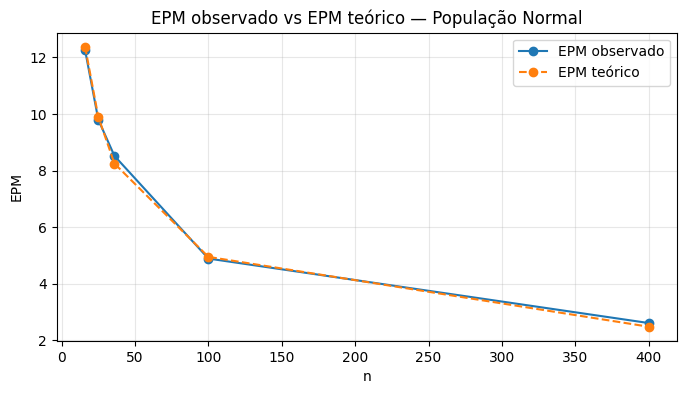

In [66]:
epms_obs = []
epms_teo = []

for n in tamanhos_n:
    epms_obs.append(round(np.std(medias_exponenciais[n]), 2))
    epms_teo.append(round(sigma / np.sqrt(n), 2))

plt.figure(figsize=(8, 4))
plt.plot(tamanhos_n, epms_obs, marker="o", label="EPM observado")
plt.plot(tamanhos_n, epms_teo, marker="o", label="EPM teórico", linestyle="--")
plt.title("EPM observado vs EPM teórico -- População Exponencial")
plt.xlabel("n")
plt.ylabel("EPM")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

c-7) O desvio padrão das médias amostrais se aproxima do valor previsto pelo TLC?

Explique usando a tabela e o gráfico do EPM observado versus EPM teórico.


In [59]:
# Sim! Podemos ver pelo gráfico que o EPM teórico anda praticamente colado com o EPM observado, proporcionalmente, a diferença entre os dois foi menor ainda do que na população normal, isso acontece porque com 1000 amostras a lei dos grandes números garante que o EPM observado se alinhe com o teórico independente da forma da população.

### **Problema 3 — Conclusão geral**

Agora responda às perguntas finais, usando os resultados obtidos nos quatro problemas anteriores.


a) A distribuição das médias amostrais é sempre normal ou depende? Justifique usando os exemplos das populações normal e exponencial.


In [59]:
# Depende. Se a população já é normal, as médias amostrais se parecem com uma normal desde n pequeno. Se a população é assimétrica como a exponencial, para n pequenos as médias ainda ficam longe de uma normal, mas quando n aumenta elas vão se aproximando cada vez mais por causa da lei dos grandes números.

b) O que acontece com a distribuição das médias amostrais quando `n` aumenta? Comente a forma, o centro e a dispersão da distribuição.


In [59]:
# Quando n aumenta, a distribuição das médias fica mais estreita e menos dispersa, se aproximando cada vez mais de uma curva normal. O centro se mantém alinhado com a média real da população (mu) em todos os valores de n.

c) O que aconteceu com o EPM quando `n` aumentou? Relacione sua resposta com a fórmula `sigma / sqrt(n)`.


In [59]:
# o n fez com que o epm se comprimisse mais em torno do centro, ele começa muito disperso, cerca de 13 de epm. depois, ele comprime mais indo em direção para se alinhar com o epm teorico, mas ainda sim, se estreitando mais em direção a media verdadeira. Isso é explicado pela fórmula sigma / sqrt(n), quanto maior o n, menor o EPM.

d) Compare o comportamento do TLC nas populações normal e exponencial. Em qual delas a aproximação normal ficou mais evidente para valores pequenos de n? Explique.


In [59]:
# A aproximação normal ficou mais evidente para valores pequenos de n na   população normal. Isso acontece porque a população normal já é simétrica, então as médias amostrais já se parecem com uma normal desde n pequeno, na exponencial, a assimetria da população faz com que seja necessário um n maior para que as médias se alinhem para uma normal.

e) Explique, com suas palavras, por que o Teorema do Limite Central é importante para a Estatística e para a Ciência de Dados.


In [59]:
# O TLC é importante porque garante que independente da forma da população, quanto maior a amostra, mais a distribuição das médias se aproxima de uma normal. Isso permite fazer cálculos, previsões e tomar decisões com mais confiança mesmo sem conhecer a forma real da população.

f) Dê um exemplo prático de uma situação real em que o TLC ajuda a justificar o uso de médias amostrais para fazer inferências sobre uma população.


In [59]:
# Em uma pesquisa de faculdade, os alunos raramente têm acesso a uma população inteira. Com uma amostra grande o suficiente, o TLC garante que a média amostral se aproxima da média real da população, permitindo fazer inferências confiáveis sem precisar coletar dados de todo mundo.

## Apêndice — Dicas de implementação

As dicas abaixo não resolvem o trabalho, mas mostram comandos úteis que podem ser adaptados pelos grupos.

- `random.choices(populacao, k=n)` seleciona uma amostra com reposição;
- `np.mean(lista)` calcula a média;
- `np.std(lista, ddof=1)` calcula o desvio padrão amostral;
- `plt.histplot(dados, stat = "density")` faz o histograma em escala de densidade;
- `norm.pdf(x, loc=media, scale=desvio)` calcula os valores da curva normal.

Para a curva normal teórica do TLC, use:

```python
media_teorica = mu
epm_teorico = sigma / np.sqrt(n)
```
